## Imports

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

import timm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


---
## 1. Helper Functions

We define reusable functions for training, evaluation, and plotting so we don't repeat ourselves for each dataset.

In [3]:
def train_one_epoch(model, loader, optimizer, criterion):
    """Run one full pass over the training set."""
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion):
    """Evaluate on the test/val set. Returns loss, accuracy, and all predictions."""
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / len(loader), correct / total, all_preds, all_labels


def train_model(model, train_loader, test_loader, epochs=5, lr=1e-3, model_name="Model"):
    """Full training loop. Returns history dict + final predictions for confusion matrix."""
    criterion = nn.CrossEntropyLoss()
    # We only optimize parameters that require grad (i.e., the unfrozen head)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    print(f"\n{'='*45}")
    print(f"  Training: {model_name}")
    print(f"{'='*45}")

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc, preds, labels = evaluate(model, test_loader, criterion)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(val_acc)
        print(f"  Epoch {epoch}/{epochs} | Train Acc: {tr_acc:.3f} | Val Acc: {val_acc:.3f} | Val Loss: {val_loss:.4f}")

    return history, preds, labels


def plot_results(histories, class_names, all_preds, all_labels, model_names, dataset_name):
    """Plot loss curves, accuracy curves, and confusion matrices for all 3 models."""
    fig = plt.figure(figsize=(20, 14))
    fig.suptitle(f'Results on {dataset_name}', fontsize=16, fontweight='bold', y=0.98)
    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

    colors = ['#2196F3', '#FF5722', '#4CAF50']
    epochs = range(1, len(histories[0]['train_acc']) + 1)

    for i, (history, name, color) in enumerate(zip(histories, model_names, colors)):
        # --- Loss curve ---
        ax_loss = fig.add_subplot(gs[0, i])
        ax_loss.plot(epochs, history['train_loss'], '--', color=color, alpha=0.7, label='Train')
        ax_loss.plot(epochs, history['val_loss'], '-', color=color, label='Val')
        ax_loss.set_title(f'{name} — Loss')
        ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('Loss')
        ax_loss.legend(); ax_loss.grid(True, alpha=0.3)

        # --- Accuracy curve ---
        ax_acc = fig.add_subplot(gs[1, i])
        ax_acc.plot(epochs, history['train_acc'], '--', color=color, alpha=0.7, label='Train')
        ax_acc.plot(epochs, history['val_acc'], '-', color=color, label='Val')
        ax_acc.set_title(f'{name} — Accuracy')
        ax_acc.set_xlabel('Epoch'); ax_acc.set_ylabel('Accuracy')
        ax_acc.set_ylim(0, 1); ax_acc.legend(); ax_acc.grid(True, alpha=0.3)

        # --- Confusion matrix ---
        ax_cm = fig.add_subplot(gs[2, i])
        cm = confusion_matrix(all_labels[i], all_preds[i])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
        disp.plot(ax=ax_cm, colorbar=False, xticks_rotation=45)
        ax_cm.set_title(f'{name} — Confusion Matrix')

    plt.savefig(f'{dataset_name.replace(" ", "_")}_results.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f"Plot saved as '{dataset_name.replace(' ', '_')}_results.png'")


def print_summary(histories, model_names, dataset_name):
    """Print a clean accuracy summary table."""
    print(f"\n{'='*45}")
    print(f"  Final Results — {dataset_name}")
    print(f"{'='*45}")
    print(f"  {'Model':<12} | {'Train Acc':>10} | {'Val Acc':>10}")
    print(f"  {'-'*38}")
    best_acc, best_name = 0, ''
    for h, name in zip(histories, model_names):
        tr = h['train_acc'][-1]
        va = h['val_acc'][-1]
        flag = ' ⬅ best' if va > best_acc else ''
        if va > best_acc:
            best_acc = va
            best_name = name
        print(f"  {name:<12} | {tr:>10.3f} | {va:>10.3f}{flag}")
    print(f"\n  🏆 Best model: {best_name} ({best_acc:.3f} val accuracy)")
    print(f"{'='*45}")

print("Helper functions defined ✓")

Helper functions defined ✓


---
#  Part 1 — CIFAR-10

CIFAR-10 has 60,000 tiny 32×32 color images across 10 classes (airplane, car, bird, etc.).
Since our pretrained models expect at least 224×224 input, we resize during preprocessing.

In [4]:
# Pretrained ImageNet models expect 224x224 images normalized with ImageNet stats
cifar_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# torchvision downloads CIFAR-10 automatically
cifar_train = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=cifar_transform)
cifar_test  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=cifar_transform)

# batch_size=64 is a good balance for Colab's free T4 GPU
cifar_train_loader = DataLoader(cifar_train, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
cifar_test_loader  = DataLoader(cifar_test,  batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

CIFAR10_CLASSES = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
print(f"Train: {len(cifar_train):,} samples | Test: {len(cifar_test):,} samples")

100%|██████████| 170M/170M [00:06<00:00, 24.7MB/s]


Train: 50,000 samples | Test: 10,000 samples


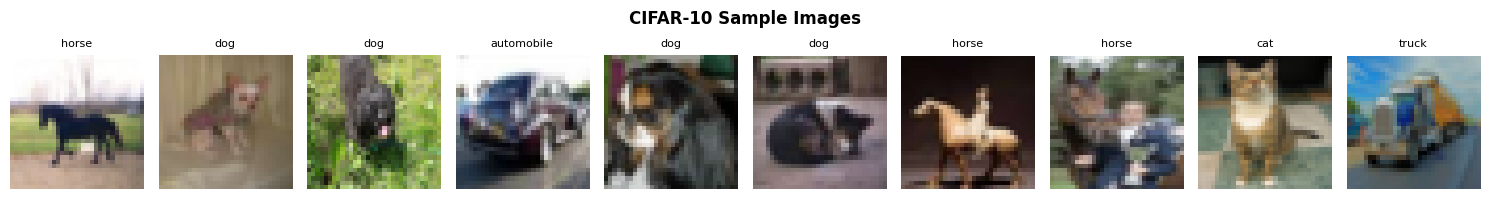

In [5]:
# Quick look at a few training samples
imgs, lbls = next(iter(DataLoader(torchvision.datasets.CIFAR10(
    root='./data', train=True,
    transform=transforms.ToTensor()),  # use raw transform for display
    batch_size=10, shuffle=True)))

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for ax, img, lbl in zip(axes, imgs, lbls):
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(CIFAR10_CLASSES[lbl], fontsize=8)
    ax.axis('off')
plt.suptitle('CIFAR-10 Sample Images', fontweight='bold')
plt.tight_layout()
plt.show()

### 1.1 Define the 3 Models for CIFAR-10

For each model:
1. Load pretrained ImageNet weights
2. Freeze all layers (no gradient updates in the backbone)
3. Replace only the final classifier head with a new one for 10 classes

In [6]:
def freeze_backbone(model):
    """Set all params to non-trainable. We'll unfreeze the head separately."""
    for param in model.parameters():
        param.requires_grad = False


def build_vgg(num_classes=10):
    # VGG-16: classic deep conv net, lots of parameters but great baseline
    model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
    freeze_backbone(model)
    # Replace only the last linear layer (4096 -> num_classes)
    in_features = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(in_features, num_classes)
    return model.to(device)


def build_resnet(num_classes=10):
    # ResNet-50: residual connections solve vanishing gradients; very efficient
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    freeze_backbone(model)
    # ResNet's last layer is model.fc
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)


def build_vit(num_classes=10):
    # ViT (Vision Transformer): splits image into patches, uses self-attention
    # timm gives us 'vit_base_patch16_224' pretrained on ImageNet-21k
    model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=num_classes)
    # Freeze everything except the classification head
    for name, param in model.named_parameters():
        if 'head' not in name:
            param.requires_grad = False
    return model.to(device)


# Count trainable parameters — should be much smaller than total params
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

for name, builder in [('VGG-16', build_vgg), ('ResNet-50', build_resnet), ('ViT-B/16', build_vit)]:
    m = builder()
    tot, train = count_params(m)
    print(f"{name:<12} | Total: {tot/1e6:.1f}M | Trainable: {train/1e3:.1f}K")
    del m  # free memory

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 93.8MB/s]


VGG-16       | Total: 134.3M | Trainable: 41.0K
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 161MB/s]


ResNet-50    | Total: 23.5M | Trainable: 20.5K


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

ViT-B/16     | Total: 85.8M | Trainable: 7.7K


### 1.2 Train All 3 Models on CIFAR-10

This will take a few minutes. Each model trains for 5 epochs.

In [7]:
EPOCHS = 5
MODEL_NAMES = ['VGG-16', 'ResNet-50', 'ViT-B/16']

cifar_histories = []
cifar_all_preds = []
cifar_all_labels = []

for name, builder in zip(MODEL_NAMES, [build_vgg, build_resnet, build_vit]):
    model = builder(num_classes=10)
    history, preds, labels = train_model(
        model, cifar_train_loader, cifar_test_loader,
        epochs=EPOCHS, lr=1e-3, model_name=name
    )
    cifar_histories.append(history)
    cifar_all_preds.append(preds)
    cifar_all_labels.append(labels)
    del model  # free GPU memory before next model
    torch.cuda.empty_cache()


  Training: VGG-16
  Epoch 1/5 | Train Acc: 0.772 | Val Acc: 0.814 | Val Loss: 0.5219
  Epoch 2/5 | Train Acc: 0.795 | Val Acc: 0.834 | Val Loss: 0.4753
  Epoch 3/5 | Train Acc: 0.801 | Val Acc: 0.831 | Val Loss: 0.4743
  Epoch 4/5 | Train Acc: 0.798 | Val Acc: 0.831 | Val Loss: 0.4849
  Epoch 5/5 | Train Acc: 0.801 | Val Acc: 0.834 | Val Loss: 0.4737

  Training: ResNet-50
  Epoch 1/5 | Train Acc: 0.748 | Val Acc: 0.795 | Val Loss: 0.5947
  Epoch 2/5 | Train Acc: 0.796 | Val Acc: 0.812 | Val Loss: 0.5397
  Epoch 3/5 | Train Acc: 0.805 | Val Acc: 0.808 | Val Loss: 0.5598
  Epoch 4/5 | Train Acc: 0.811 | Val Acc: 0.813 | Val Loss: 0.5395
  Epoch 5/5 | Train Acc: 0.813 | Val Acc: 0.822 | Val Loss: 0.5135

  Training: ViT-B/16
  Epoch 1/5 | Train Acc: 0.933 | Val Acc: 0.945 | Val Loss: 0.1702
  Epoch 2/5 | Train Acc: 0.953 | Val Acc: 0.951 | Val Loss: 0.1594
  Epoch 3/5 | Train Acc: 0.958 | Val Acc: 0.949 | Val Loss: 0.1634
  Epoch 4/5 | Train Acc: 0.960 | Val Acc: 0.948 | Val Loss: 0.16

### 1.3 Results & Plots — CIFAR-10

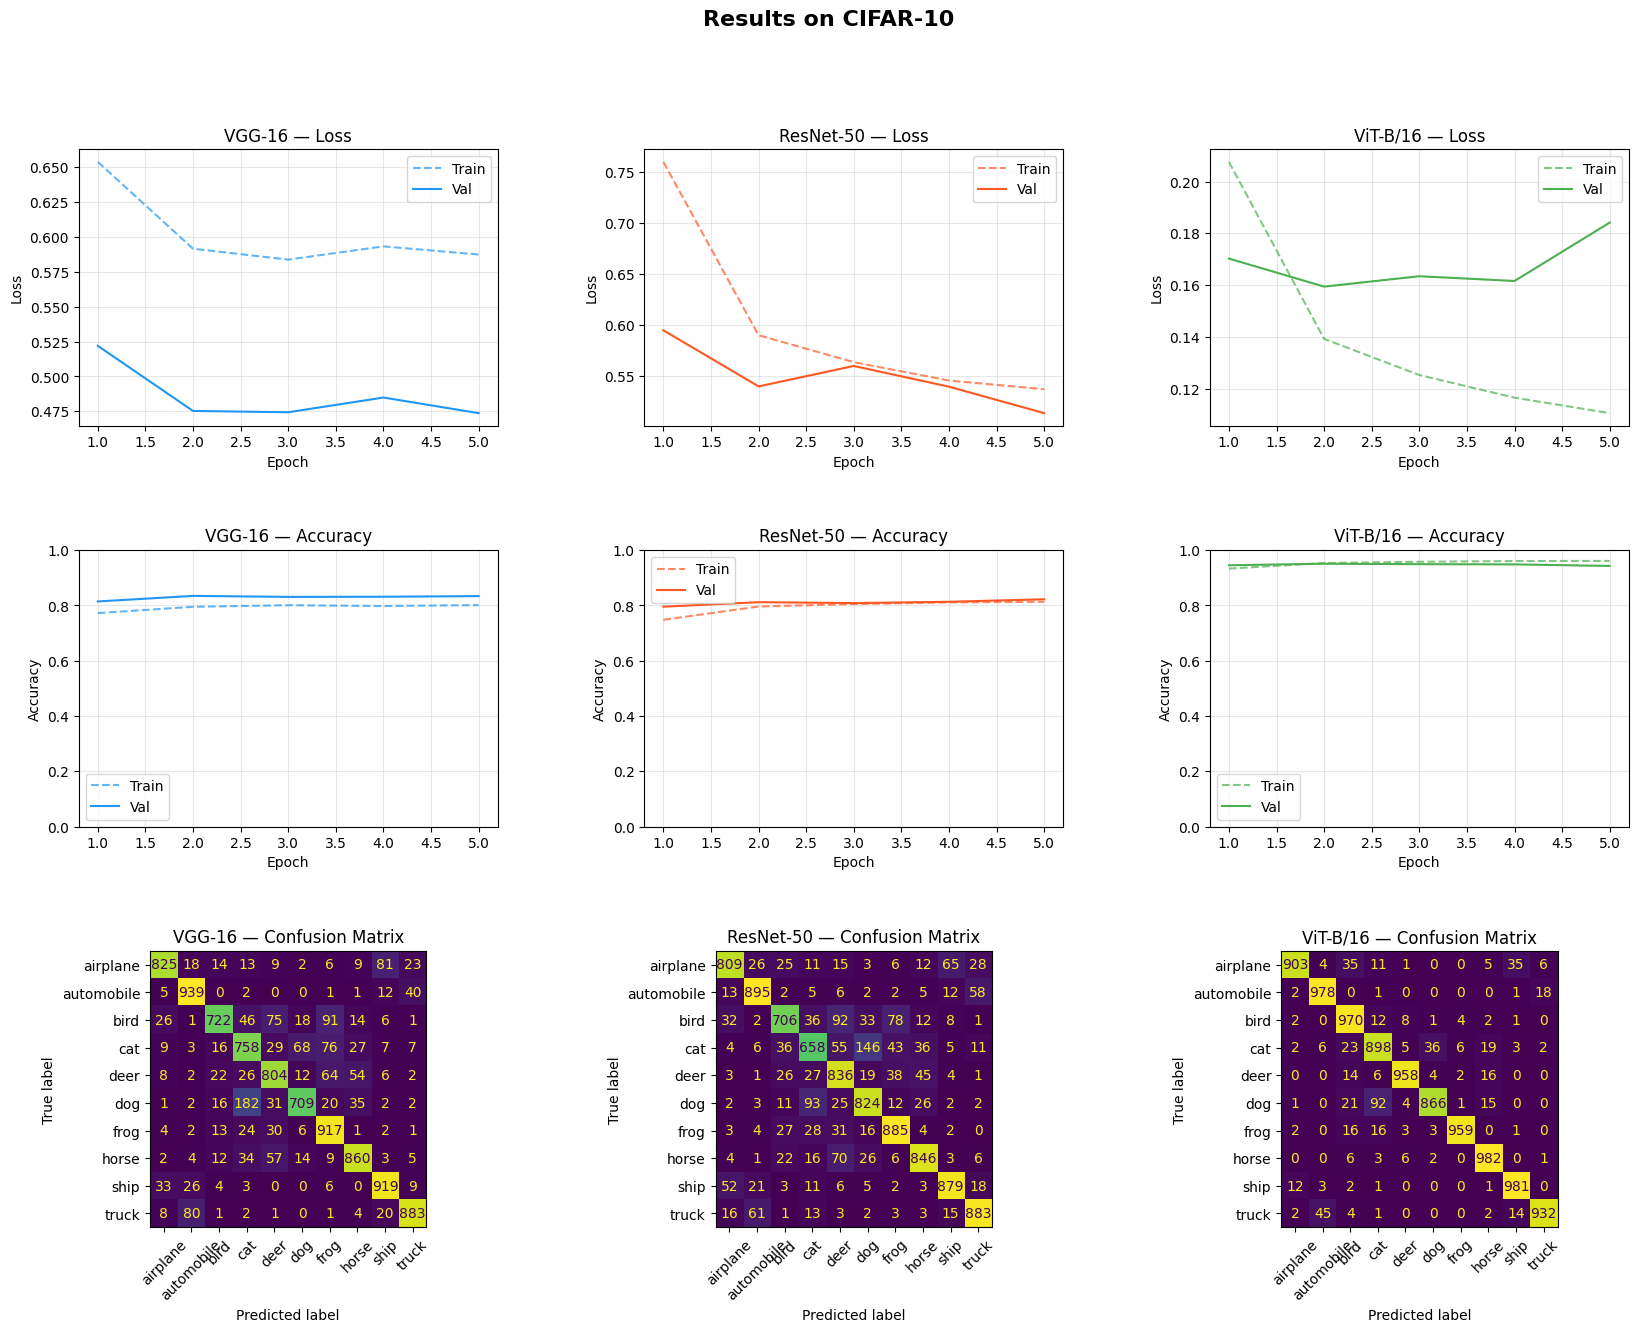

Plot saved as 'CIFAR-10_results.png'

  Final Results — CIFAR-10
  Model        |  Train Acc |    Val Acc
  --------------------------------------
  VGG-16       |      0.801 |      0.834 ⬅ best
  ResNet-50    |      0.813 |      0.822
  ViT-B/16     |      0.961 |      0.943 ⬅ best

  🏆 Best model: ViT-B/16 (0.943 val accuracy)


In [8]:
plot_results(
    cifar_histories, CIFAR10_CLASSES,
    cifar_all_preds, cifar_all_labels,
    MODEL_NAMES, 'CIFAR-10'
)
print_summary(cifar_histories, MODEL_NAMES, 'CIFAR-10')

## Conclusion 

- the best model is vit-b /16 achieving acc of 94% but it takes about 20 min per epoch 
- vgg achieved acc of 83% and takes about 13 min per epoch 
- ResNet-50 achieved 82% acc and takes about 10 min per epoch 

So there is a tradeoff between time and acc if we need beter acc despite the time it takes we can use VIT and if we need balancing btn time and acc so ResNet will be a good choise

---
#  Part 2 — Fashion-MNIST

Fashion-MNIST is a drop-in replacement for classic MNIST: 70,000 grayscale 28×28 images of clothing items across 10 classes.

One key difference from CIFAR-10: **grayscale (1 channel) vs RGB (3 channels)**. Pretrained models expect 3-channel input, so we repeat the single channel 3 times.

In [9]:
# Grayscale -> repeat channel 3x to match what pretrained models expect
fmnist_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),  # 1-channel -> 3-channel
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

fmnist_train = torchvision.datasets.FashionMNIST(root='./data', train=True,  download=True, transform=fmnist_transform)
fmnist_test  = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=fmnist_transform)

fmnist_train_loader = DataLoader(fmnist_train, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
fmnist_test_loader  = DataLoader(fmnist_test,  batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

FMNIST_CLASSES = ['T-shirt','Trouser','Pullover','Dress','Coat',
                  'Sandal','Shirt','Sneaker','Bag','Ankle boot']
print(f"Train: {len(fmnist_train):,} samples | Test: {len(fmnist_test):,} samples")

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.81MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.3MB/s]

Train: 60,000 samples | Test: 10,000 samples


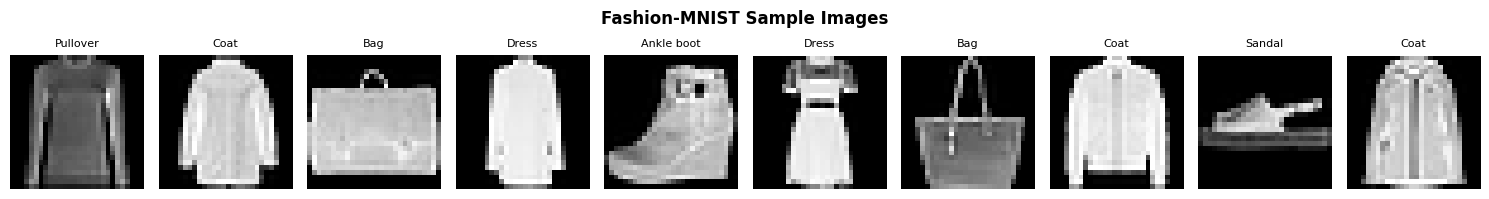

In [10]:
# Visualize some Fashion-MNIST samples (raw, before transform)
raw_imgs, raw_lbls = next(iter(DataLoader(torchvision.datasets.FashionMNIST(
    root='./data', train=True, transform=transforms.ToTensor()),
    batch_size=10, shuffle=True)))

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for ax, img, lbl in zip(axes, raw_imgs, raw_lbls):
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(FMNIST_CLASSES[lbl], fontsize=8)
    ax.axis('off')
plt.suptitle('Fashion-MNIST Sample Images', fontweight='bold')
plt.tight_layout()
plt.show()

### 2.1 Train All 3 Models on Fashion-MNIST

In [11]:
fmnist_histories = []
fmnist_all_preds = []
fmnist_all_labels = []

for name, builder in zip(MODEL_NAMES, [build_vgg, build_resnet, build_vit]):
    model = builder(num_classes=10)
    history, preds, labels = train_model(
        model, fmnist_train_loader, fmnist_test_loader,
        epochs=EPOCHS, lr=1e-3, model_name=name
    )
    fmnist_histories.append(history)
    fmnist_all_preds.append(preds)
    fmnist_all_labels.append(labels)
    del model
    torch.cuda.empty_cache()


  Training: VGG-16
  Epoch 1/5 | Train Acc: 0.795 | Val Acc: 0.849 | Val Loss: 0.4274
  Epoch 2/5 | Train Acc: 0.814 | Val Acc: 0.850 | Val Loss: 0.4164
  Epoch 3/5 | Train Acc: 0.819 | Val Acc: 0.849 | Val Loss: 0.4142
  Epoch 4/5 | Train Acc: 0.820 | Val Acc: 0.859 | Val Loss: 0.3929
  Epoch 5/5 | Train Acc: 0.819 | Val Acc: 0.860 | Val Loss: 0.3847

  Training: ResNet-50
  Epoch 1/5 | Train Acc: 0.793 | Val Acc: 0.836 | Val Loss: 0.4711
  Epoch 2/5 | Train Acc: 0.832 | Val Acc: 0.839 | Val Loss: 0.4544
  Epoch 3/5 | Train Acc: 0.845 | Val Acc: 0.853 | Val Loss: 0.4140
  Epoch 4/5 | Train Acc: 0.850 | Val Acc: 0.828 | Val Loss: 0.4743
  Epoch 5/5 | Train Acc: 0.856 | Val Acc: 0.845 | Val Loss: 0.4401

  Training: ViT-B/16
  Epoch 1/5 | Train Acc: 0.857 | Val Acc: 0.873 | Val Loss: 0.3551
  Epoch 2/5 | Train Acc: 0.886 | Val Acc: 0.875 | Val Loss: 0.3555
  Epoch 3/5 | Train Acc: 0.891 | Val Acc: 0.891 | Val Loss: 0.3113
  Epoch 4/5 | Train Acc: 0.897 | Val Acc: 0.887 | Val Loss: 0.32

### 2.2 Results & Plots — Fashion-MNIST

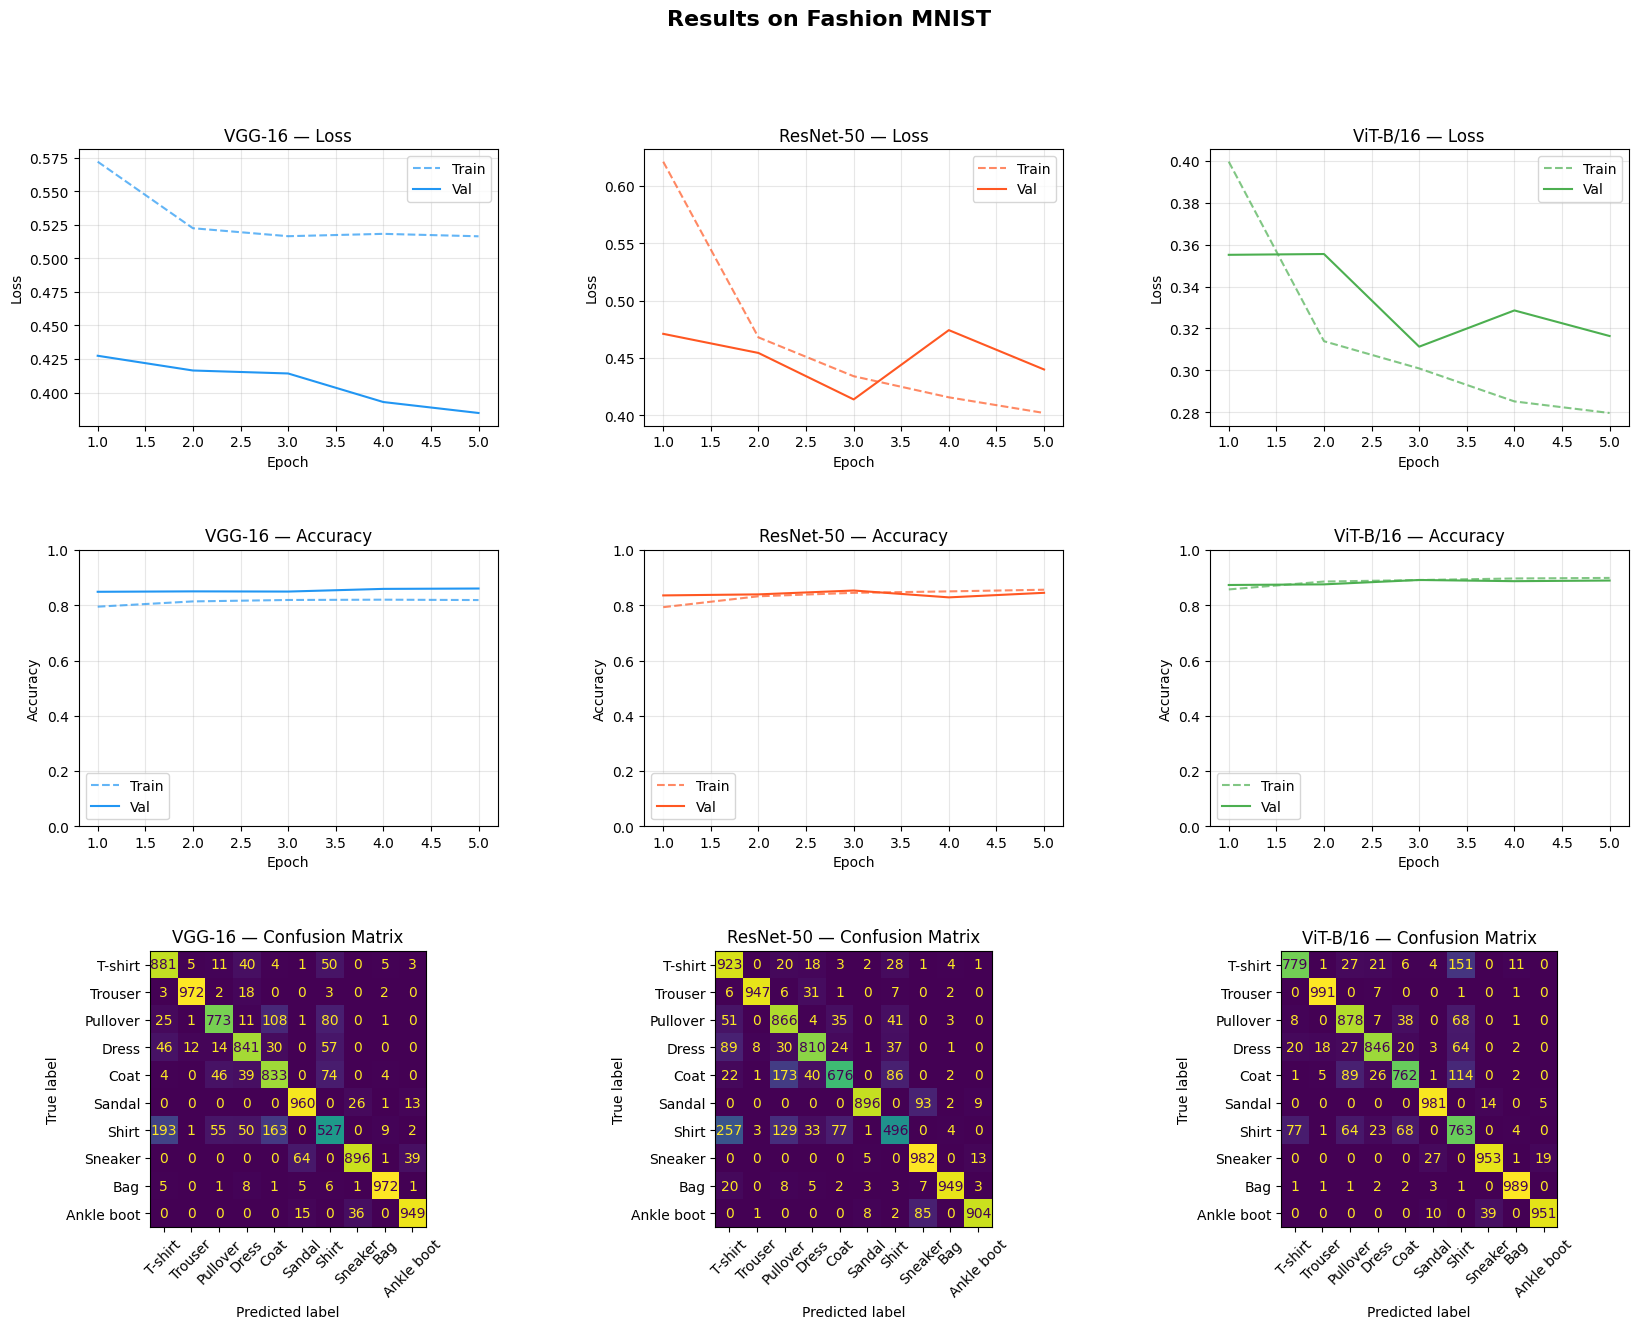

Plot saved as 'Fashion_MNIST_results.png'

  Final Results — Fashion-MNIST
  Model        |  Train Acc |    Val Acc
  --------------------------------------
  VGG-16       |      0.819 |      0.860 ⬅ best
  ResNet-50    |      0.856 |      0.845
  ViT-B/16     |      0.899 |      0.889 ⬅ best

  🏆 Best model: ViT-B/16 (0.889 val accuracy)


In [12]:
plot_results(
    fmnist_histories, FMNIST_CLASSES,
    fmnist_all_preds, fmnist_all_labels,
    MODEL_NAMES, 'Fashion MNIST'
)
print_summary(fmnist_histories, MODEL_NAMES, 'Fashion-MNIST')

## Conclusion 

- the best model is vit-b /16 achieving acc of 88.9% but it takes about 20 min per epoch 
- vgg achieved acc of 86% and takes about 13 min per epoch 
- ResNet-50 achieved 84.5% acc and takes about 10 min per epoch 


Here i think the best choise is VGG because it achieved good acc of 86% and the time per epoch however the VIT achieve better acc but in a long time 

---
# 📊 Final Cross-Dataset Comparison

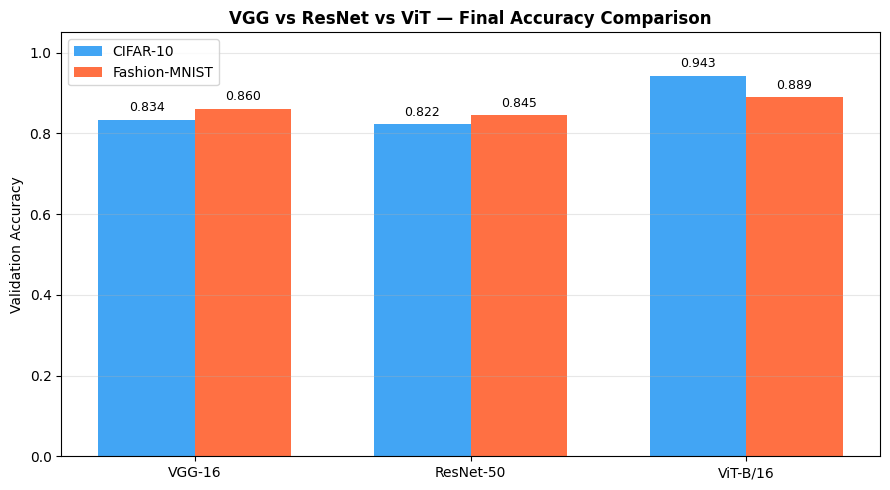

Comparison chart saved ✓


In [13]:
# Side-by-side bar chart comparing final val accuracy on both datasets
cifar_accs  = [h['val_acc'][-1] for h in cifar_histories]
fmnist_accs = [h['val_acc'][-1] for h in fmnist_histories]

x = np.arange(len(MODEL_NAMES))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, cifar_accs,  width, label='CIFAR-10',      color='#2196F3', alpha=0.85)
bars2 = ax.bar(x + width/2, fmnist_accs, width, label='Fashion-MNIST', color='#FF5722', alpha=0.85)

ax.set_ylabel('Validation Accuracy')
ax.set_title('VGG vs ResNet vs ViT — Final Accuracy Comparison', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(MODEL_NAMES)
ax.set_ylim(0, 1.05); ax.legend()
ax.grid(True, axis='y', alpha=0.3)

# Label bars with exact values
for bar in bars1 + bars2:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('final_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("Comparison chart saved ✓")